#### 주성분 분석(PCA : Principal Component Analysis)
: 고차원의 데이터를 저차원의 데이터로 환원시키는 방법

In [2]:
import numpy as np

In [3]:
fruits = np.load("../Data/fruits.npy")
fruits.shape

(300, 100, 100)

In [4]:
# 2차원 배열로 변경하기
fruits_2d = fruits.reshape(-1, 100*100)
fruits_2d.shape

(300, 10000)

---
#### PCA 모델 구성하기

In [5]:
from sklearn.decomposition import PCA

In [6]:
pca = PCA(n_components=50)
# 300개의 데이터중 확실한 Feature의 특징으로 포함한 주성분 50개만 선택
pca.fit(fruits_2d)

,n_components,50
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [7]:
# 축소된 차원 크기 확인하기
pca.components_.shape

(50, 10000)

In [8]:
import matplotlib.pyplot as plt

In [ ]:
def draw_fruits(arr, ratio=1):
    n=len(arr)
    rows=int(np.ceil(n/10))

    cols=n if rows<2

In [ ]:
# Feature를 다시 2차원 배열로 바꾸어야 그림을 그릴수 있음
draw_fruits(pca.components_.reshape(-1, 100, 100))

In [10]:
# 행의 갯수는 원본과 동일하게 하고 Feature의 특성을 50개의 주성분으로 변경
print(fruits_2d.shape)
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)

(300, 10000)
(300, 50)


In [ ]:
draw_fruits(fruits_pca.reshape(-1., 10, 5))

----
#### 원본 데이터 재구성

In [11]:
fruits_inverse = pca.inverse_transform(fruits_pca)
print(fruits_inverse.shape)

(300, 10000)


In [12]:
# 그림을 그리기 위해 2차원 확장
fruits_reconstruct = fruits_inverse.reshape(-1, 100, 100)
fruits_reconstruct.shape

(300, 100, 100)

In [ ]:
for start in [0, 100, 200]:
    draw_fruits(fruits_reconstruct[start:start+100])
    print('\n')

> 1/200의 데이터 특성만 가지고도 전반적으로 배경은 깨끗하지 않으나 물체의 구분은 가능하다.

----
#### 설명된 분산
: 주성분으로 구성할 때 원본데이터의 분산을 어느 정도 유지하고 있는지 확인하는 방법

In [13]:
np.sum(pca.explained_variance_ratio_) # 50개의 주성분 데이터

np.float64(0.922269339866876)

> 50개의 주성분이 전체 데이터의 92%정도의 복원은 가능하다.

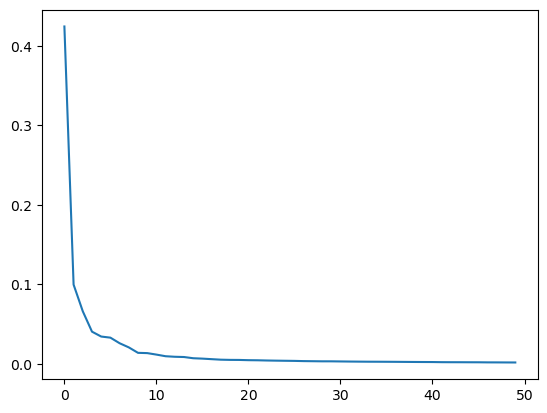

In [14]:
# 그래프 그리기
plt.plot(pca.explained_variance_ratio_)
plt.show()

----
#### 주성분을 10개만 선정해서 해보자

In [15]:
pca10 = PCA(n_components=10)
pca10.fit(fruits_2d)

,n_components,10
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [16]:
pca10.components_.shape

(10, 10000)

In [17]:
frutis_pca10 = pca10.transform(fruits_2d)
frutis_pca10.shape

(300, 10)

In [19]:
fruits_inverse10 = pca10.inverse_transform(frutis_pca10)
fruits_inverse10.shape

(300, 10000)

In [20]:
# 그림을 그리기 위해 2차원 확장
fruits_reconstruct10 = fruits_inverse10.reshape(-1, 100, 100)
fruits_reconstruct10.shape

(300, 100, 100)

In [ ]:
for start in [0, 100, 200]:
    draw_fruits(fruits_reconstruct10[start:start+100])
    print('\n')

In [21]:
np.sum(pca10.explained_variance_ratio_)

np.float64(0.7711096075479617)

----
#### 주성분을 30개 선정

In [22]:
pca30 = PCA(n_components=30)
pca30.fit(fruits_2d)

,n_components,30
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [23]:
pca30.components_.shape

(30, 10000)

In [24]:
frutis_pca30 = pca30.transform(fruits_2d)
frutis_pca30.shape

(300, 30)

In [25]:
fruits_inverse30 = pca30.inverse_transform(frutis_pca30)
fruits_inverse30.shape

(300, 10000)

In [26]:
# 그림을 그리기 위해 2차원 확장
fruits_reconstruct30 = fruits_inverse30.reshape(-1, 100, 100)
fruits_reconstruct30.shape

(300, 100, 100)

In [ ]:
for start in [0, 100, 200]:
    draw_fruits(fruits_reconstruct30[start:start+100])
    print('\n')

In [28]:
np.sum(pca30.explained_variance_ratio_)

np.float64(0.8793070090978329)

----
#### 로지스틱 회귀분석에 주성분 분석을 대입하여 사용해보기

In [29]:
from sklearn.linear_model import LogisticRegression

In [30]:
lr = LogisticRegression()

In [36]:
# 로지스틱 회귀분석은 지도학습 target이 필요하다.
target = np.array(
    [0] * 100 +
    [1] * 100 +
    [2] * 100
)
target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [37]:
# 교차검증을 통해 실시
from sklearn.model_selection import cross_validate

In [41]:
scores = cross_validate(lr, fruits_2d, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.17682366371154784


> 정확도는 99.7% 정도이며 계산에 필요한 시간은 0.17초 정도 나왔다.

#### 300 * 50 으로 구성된 주성분 분석으로 구성된 데이터를 확인

In [42]:
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.007865810394287109


> 정확도는 99.7% 정도이며 계산에 필요한 시간은 0.007초 정도 나왔다.

In [44]:
scores = cross_validate(lr, frutis_pca10, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.007117080688476563


----
#### 주성분 분석의 분산 크기를 정해 사용하기

In [61]:
pca = PCA(n_components=0.5) # n_components를 실수로 정하면 분산의 percent를 기입
pca.fit(fruits_2d)

,n_components,0.5
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [62]:
pca.n_components_

np.int64(2)

In [63]:
fruits_pca = pca.transform(fruits_2d)
fruits_pca.shape

(300, 2)

In [64]:
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9933333333333334
0.026485633850097657


c:\Users\tjoeun\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\tjoeun\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also 

----
#### k-Means에 주성분 분석 적용해보기

In [56]:
from sklearn.cluster import KMeans

In [65]:
km = KMeans(n_clusters=3)
km.fit(fruits_pca)

c:\Users\tjoeun\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [66]:
np.unique(km.labels_, return_counts=True)

(array([0, 1, 2], dtype=int32), array([110,  99,  91]))

In [ ]:
# 그림으로 확인하기
for label in range(0, 2+1):
    draw_fruits(fruits[km.labels_ == label])
    print("\n")

----
#### 산포도로 확인하기

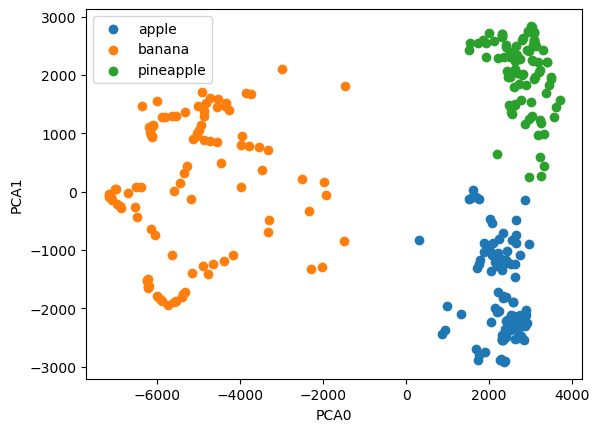

In [70]:
for label in range(0, 2+1):
    data = fruits_pca[km.labels_ == label]
    plt.scatter(data[:,0], data[:,1])

plt.legend(['apple', 'banana', 'pineapple'])
plt.xlabel('PCA0')
plt.ylabel('PCA1')

plt.show()

> 현재 PCA는 2개이다.
뚜렷한 분포가 확인 가능하다.    
즉, 차원이 큰 데이터의 분포를 확인할 경우에는 주성분 분석을 활용한다.

In [71]:
1920 * 1080

2073600